##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
%pip install -q keras-cv tensorflow-datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 9.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 30.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras_cv
import matplotlib.pyplot as plt

In [ ]:
prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format="xywh",
    from_logits=True,
    iou_threshold=0.2,
    confidence_threshold=0.5,
)

detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
    prediction_decoder=prediction_decoder,
)

inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

voc = tfds.load("voc/2012", split="validation", as_supervised=False)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

...

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.7M4JA6_5.0.0/voc-train.tfrecord*...:   0%|          | …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.7M4JA6_5.0.0/voc-validation.tfrecord*...:   0%|       …

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2012/5.0.0. Subsequent calls will reuse this data.


ValueError: all input arrays must have the same shape

In [5]:
wanted = set()
images = []
true_objects = []

for sample in voc:
    img = sample["image"]
    labels = sample["objects"]["label"]
    if tf.shape(labels)[0] == 0:
        continue

    first = int(labels[0].numpy())
    if first in wanted:
        continue

    wanted.add(first)
    images.append(img)
    true_objects.append(first)

    if len(images) == 5:
        break

resized_images = tf.stack([inference_resizing(tf.expand_dims(im, 0))[0] for im in images], axis=0)
resized_images = tf.cast(resized_images, tf.uint8).numpy()

pred = detector.predict(resized_images, verbose=0)

boxes = pred["boxes"]
classes = pred["classes"]
scores = pred["confidence"]

class_names = [
    "aeroplane","bicycle","bird","boat","bottle","bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person","pottedplant","sheep","sofa","train","tvmonitor"
]

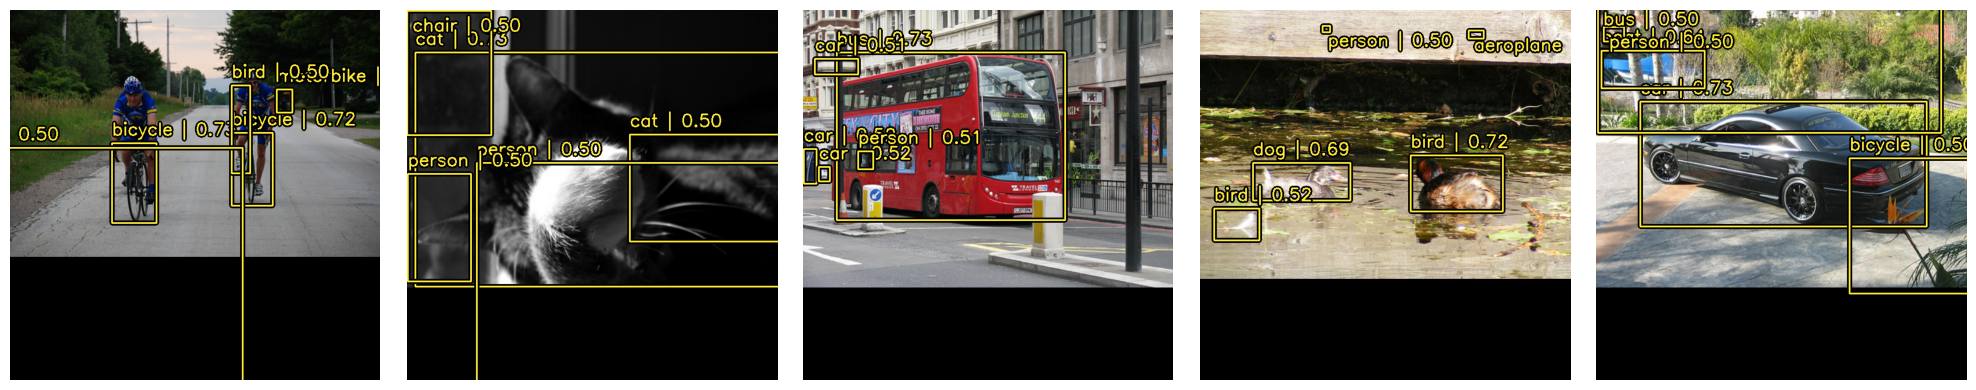

Image 1 | True class: bicycle | Top detection: bicycle (0.725)
Image 2 | True class: cat | Top detection: cat (0.727)
Image 3 | True class: bus | Top detection: bus (0.730)
Image 4 | True class: bird | Top detection: bird (0.724)
Image 5 | True class: car | Top detection: car (0.726)


In [10]:
# keep top K boxes per image by confidence
K = 5
topk = np.argsort(scores, axis=1)[:, ::-1][:, :K]

boxes_k   = np.take_along_axis(boxes,   topk[..., None], axis=1)
classes_k = np.take_along_axis(classes, topk,            axis=1)
scores_k  = np.take_along_axis(scores,  topk,            axis=1)

keras_cv.visualization.plot_bounding_box_gallery(
    resized_images,
    y_true=None,
    y_pred={"boxes": boxes_k, "classes": classes_k, "confidence": scores_k},
    class_mapping={i: n for i, n in enumerate(class_names)},
    bounding_box_format="xywh",
    value_range=(0, 255),
    rows=1,
    cols=5,
    scale=4,
)
plt.show()

for i in range(5):
    best = int(classes_k[i][0])
    best_score = float(scores_k[i][0])
    print(
        f"Image {i+1} | True class: {class_names[true_objects[i]]} | "
        f"Top detection: {class_names[best]} ({best_score:.3f})"
    )